v_c(R0=8.2 kpc) = 244.0 km/s  (McMillan 2017 quote: 232.8 +/- 3.0 km/s)
  Halo (DM)       :  152.1 km/s
  Bulge           :   48.1 km/s
  Thin disc       :  141.0 km/s
  Thick disc      :   69.6 km/s
  HI gas disc     :   32.0 km/s
  H$_2$ gas disc  :   91.3 km/s


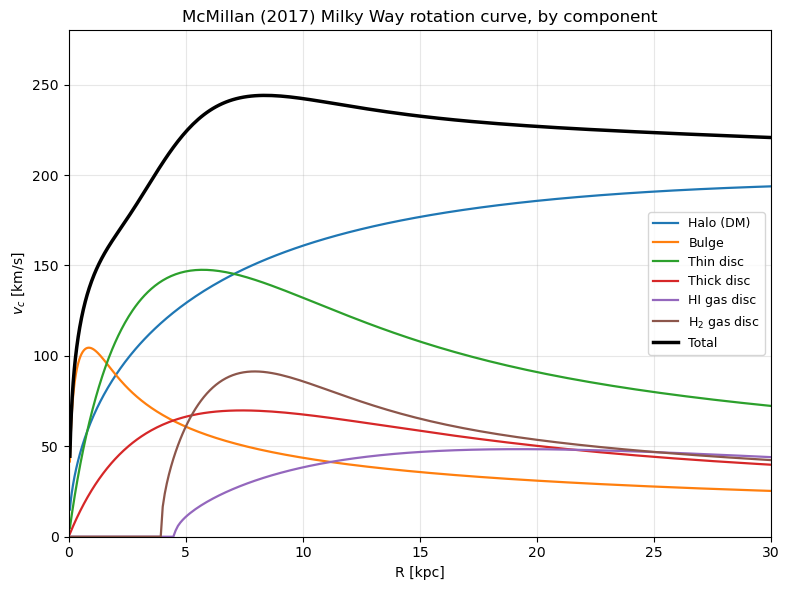

In [2]:
"""
Rotation curve of the McMillan (2017) Milky Way mass model, component by component.

Method
------
- Halo (generalized NFW, gamma=1): closed-form F_R(R) -- see derivation.
- Bulge: flattened (q=0.5) but not a disk -> full Legendre multipole
  expansion of rho(r,theta) directly.
- Thin disk, thick disk, HI disk, H2 disk: Kuijken & Dubinski (1995)
  disk-ansatz + residual. The ansatz term is EXACTLY ZERO in the
  z=0 plane (since H(0)=0 by construction), so the in-plane radial
  force of every disk comes entirely from the multipole expansion of
  the (mildly flattened) residual density.

Everything funnels through one generic routine, `multipole_FR`, that
takes any axisymmetric density rho(r,mu) [mu = cos(theta)] and returns
F_R(R, z=0) = -sum_l Phi_l'(R) P_l(0).

Units: kpc, km/s, Msun. G in these units:
    G = 4.300917270e-6 kpc (km/s)^2 / Msun
"""

import numpy as np
from scipy.integrate import cumulative_trapezoid, quad
from scipy.special import eval_legendre
import matplotlib.pyplot as plt

G = 4.300917270e-6  # kpc (km/s)^2 / Msun

# Default multipole order. See note near r_grid setup below re: numerical
# stability of the direct r^(l+2) / r^(1-l) multipole sum at high l.
LMAX = 8

# ----------------------------------------------------------------------
# 1. Generic multipole solver
# ----------------------------------------------------------------------

def multipole_FR(rho_func, r_grid, lmax=LMAX, n_mu=80):
    """
    Radial force F_R(R, z=0) for an axisymmetric density rho_func(r, mu),
    mu = cos(theta), evaluated via a Legendre multipole expansion.

    rho_func(r_col, mu_row) must accept r_col of shape (N,1) and
    mu_row of shape (1,M) and return an (N,M) array (broadcasting).

    r_grid : 1D array of spherical radii (kpc), used BOTH as the
             integration grid (0 -> r_grid[-1] essentially playing the
             role of "infinity") and as the R values at which we want
             the force. Must be sorted ascending and start close to 0.
    """
    mu_nodes, mu_weights = np.polynomial.legendre.leggauss(n_mu)   # nodes in [-1,1]
    r_col = r_grid[:, None]          # (N,1)
    mu_row = mu_nodes[None, :]       # (1,M)

    FR = np.zeros_like(r_grid)

    for l in range(0, lmax + 1, 2):  # only even l for a z -> -z symmetric density
        Pl_mu = eval_legendre(l, mu_nodes)                 # (M,)
        vals = rho_func(r_col, mu_row)                      # (N,M)
        rho_l = 0.5 * (2 * l + 1) * (vals * (Pl_mu * mu_weights)[None, :]).sum(axis=1)  # (N,)

        integrand_lt = rho_l * r_grid ** (l + 2)
        integrand_gt = rho_l * r_grid ** (1 - l)

        # M_lt(r) = int_0^r ...  : dominated by the *largest* r in [0,r] for
        # a well-behaved rho_l, so a forward cumulative sum is stable.
        M_lt = cumulative_trapezoid(integrand_lt, r_grid, initial=0.0)

        # M_gt(r) = int_r^rmax ... : for l>=2 this integrand is typically
        # dominated by SMALL r (rho_l needn't vanish faster than r^l at the
        # centre for a flattened/cuspy density). Computing it as
        # "total - cumulative(r)" then subtracts two nearly-equal huge
        # numbers and loses all precision. Instead accumulate directly
        # from r_max backward, so we never touch the large near-origin
        # values unless we are actually asking for M_gt at small r.
        seg = 0.5 * (integrand_gt[:-1] + integrand_gt[1:]) * np.diff(r_grid)  # (N-1,)
        M_gt = np.concatenate([np.cumsum(seg[::-1])[::-1], [0.0]])            # (N,)

        # avoid 0**negative at r_grid[0]
        with np.errstate(divide='ignore', invalid='ignore'):
            Phi_l_prime = (4 * np.pi * G / (2 * l + 1)) * (
                (l + 1) * M_lt / r_grid ** (l + 2) - l * r_grid ** (l - 1) * M_gt
            )
        Phi_l_prime = np.nan_to_num(Phi_l_prime)

        FR += -Phi_l_prime * eval_legendre(l, 0.0)

    return FR


# ----------------------------------------------------------------------
# 2. Halo: generalized NFW, closed form (gamma = 1 -> standard NFW)
# ----------------------------------------------------------------------

def halo_FR(R, rho0_h, r_h):
    x = R / r_h
    Menc = 4 * np.pi * rho0_h * r_h**3 * (np.log(1 + x) - x / (1 + x))
    return -G * Menc / R**2


# ----------------------------------------------------------------------
# 3. Bulge: Bissantz & Gerhard (2002)-type profile, axisymmetric, q=0.5
# ----------------------------------------------------------------------

def make_bulge_rho(rho0_b, r0, rcut, alpha, q):
    def rho(r, mu):
        rp = r * np.sqrt(mu**2 + (1 - mu**2) / q**2)
        return rho0_b / (1 + rp / r0) ** alpha * np.exp(-(rp / rcut) ** 2)
    return rho


# ----------------------------------------------------------------------
# 4. Disks: stellar (pure exponential) and gas (exponential + inner hole)
#    Both go through the SAME residual-density construction.
# ----------------------------------------------------------------------

def make_stellar_disk_funcs(Sigma0, Rd, zd):
    """ f(x) = Sigma0/(2 zd) exp(-x/Rd),  h(z) = exp(-|z|/zd) """
    A = Sigma0 / (2 * zd)

    def f(x):
        return A * np.exp(-x / Rd)

    def fp(x):      # f'(x)
        return -f(x) / Rd

    def fpp(x):     # f''(x)
        return f(x) / Rd**2

    def h(z):
        return np.exp(-np.abs(z) / zd)

    def H(z):
        return 4 * np.pi * G * zd * (np.abs(z) + zd * (np.exp(-np.abs(z) / zd) - 1))

    def Hp(z):
        return 4 * np.pi * G * zd * np.sign(z) * (1 - np.exp(-np.abs(z) / zd))

    return f, fp, fpp, h, H, Hp


def gas_disk_sigma0(M_target, Rd, Rm):
    """Solve Sigma_g such that 2*pi*int Sigma_g*exp(-Rm/R-R/Rd)*R dR = M_target."""
    I, _ = quad(lambda R: np.exp(-Rm / R - R / Rd) * R, 1e-6, 200 * Rd, limit=200)
    return M_target / (2 * np.pi * I)


def make_gas_disk_funcs(Sigma_g, Rd, Rm, zd):
    """ f(x) = Sigma_g/(4 zd) exp(-Rm/x - x/Rd),  h(z) = sech^2(z/(2 zd)) """
    A = Sigma_g / (4 * zd)

    def f(x):
        x = np.clip(x, 1e-8, None)
        return A * np.exp(-Rm / x - x / Rd)

    def g(x):        # d(ln f)/dx
        return Rm / x**2 - 1 / Rd

    def fp(x):
        return f(x) * g(x)

    def fpp(x):
        x = np.clip(x, 1e-8, None)
        return f(x) * (g(x)**2 - 2 * Rm / x**3)

    def h(z):
        # stable sech^2(x) = 4 e^{-2|x|} / (1 + e^{-2|x|})^2  (avoids cosh overflow)
        x = np.abs(z) / (2 * zd)
        e = np.exp(-2 * x)
        return 4 * e / (1 + e) ** 2

    def H(z):
        # stable log(cosh(x)) = |x| + log1p(e^{-2|x|}) - log(2)
        x = np.abs(z) / (2 * zd)
        logcosh = x + np.log1p(np.exp(-2 * x)) - np.log(2.0)
        return 16 * np.pi * G * zd**2 * logcosh

    def Hp(z):
        return 8 * np.pi * G * zd * np.tanh(z / (2 * zd))

    return f, fp, fpp, h, H, Hp


def make_disk_residual_rho(f, fp, fpp, h, H, Hp):
    """Residual density tilde_rho(r,mu) for the disk-ansatz method.
    (The ansatz term f(r)H(z) itself vanishes at z=0 automatically.)"""
    def rho(r, mu):
        R = r * np.sqrt(np.clip(1 - mu**2, 0, None))
        z = r * mu
        term1 = h(z) * (f(R) - f(r))
        term2 = -(1.0 / (4 * np.pi * G)) * (
            fpp(r) * H(z) + (2 * fp(r) / r) * (H(z) + z * Hp(z))
        )
        return term1 + term2
    return rho


# ----------------------------------------------------------------------
# 5. McMillan (2017) best-fit parameters (approximate published values)
# ----------------------------------------------------------------------

params = dict(
    bulge=dict(rho0_b=9.93e10, r0=0.075, rcut=2.1, alpha=1.8, q=0.5),
    thin=dict(Sigma0=8.96e8, Rd=2.5, zd=0.3),
    thick=dict(Sigma0=1.83e8, Rd=3.02, zd=0.9),
    HI=dict(M=1.1e10, Rd=7.0, Rm=4.0, zd=0.085),
    H2=dict(M=1.2e10, Rd=1.5, Rm=12.0, zd=0.045),
    halo=dict(rho0_h=8.55e6, r_h=19.6),
)

# ----------------------------------------------------------------------
# 6. Compute F_R(R,0) for every component on a common radial grid
# ----------------------------------------------------------------------

r_min, r_max, N = 1e-2, 300.0, 6000           # kpc; r_max acts as numerical "infinity"
r_grid = np.geomspace(r_min, r_max, N)
R_plot = np.geomspace(0.05, 30.0, 300)        # radii we actually want to plot (kpc)

# NOTE on numerical stability: the direct multipole sum involves r^(l+2) and
# r^(1-l), whose dynamic range grows fast with l. Combined with a grid that
# reaches very small r, this causes catastrophic cancellation for large l.
# A modest lmax (~8, set above) already converges well for the mild
# flattening (q=0.5, disk residuals) used here; push it higher only together
# with a larger r_min and/or arbitrary-precision integration if needed.

results = {}

# --- halo (analytic) ---
FR_halo_grid = halo_FR(r_grid, **params['halo'])
results['Halo (DM)'] = np.interp(R_plot, r_grid, FR_halo_grid)

# --- bulge (multipole) ---
rho_bulge = make_bulge_rho(**params['bulge'])
FR_bulge_grid = multipole_FR(rho_bulge, r_grid, lmax=LMAX)
results['Bulge'] = np.interp(R_plot, r_grid, FR_bulge_grid)

# --- thin & thick stellar disks (multipole, residual only) ---
for name, key in [('Thin disc', 'thin'), ('Thick disc', 'thick')]:
    f, fp, fpp, h, H, Hp = make_stellar_disk_funcs(**params[key])
    rho_res = make_disk_residual_rho(f, fp, fpp, h, H, Hp)
    FR_grid = multipole_FR(rho_res, r_grid, lmax=LMAX)
    results[name] = np.interp(R_plot, r_grid, FR_grid)

# --- HI & H2 gas disks (multipole, residual only) ---
for name, key in [('HI gas disc', 'HI'), ('H$_2$ gas disc', 'H2')]:
    p = params[key]
    Sigma_g = gas_disk_sigma0(p['M'], p['Rd'], p['Rm'])
    f, fp, fpp, h, H, Hp = make_gas_disk_funcs(Sigma_g, p['Rd'], p['Rm'], p['zd'])
    rho_res = make_disk_residual_rho(f, fp, fpp, h, H, Hp)
    FR_grid = multipole_FR(rho_res, r_grid, lmax=LMAX)
    results[name] = np.interp(R_plot, r_grid, FR_grid)

# --- total and circular velocities ---
FR_total = sum(results.values())
vc_total = np.sqrt(np.clip(R_plot * (-FR_total), 0, None))

vc = {name: np.sqrt(np.clip(R_plot * (-FR), 0, None)) for name, FR in results.items()}

# ----------------------------------------------------------------------
# 7. Plot
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))
for name, v in vc.items():
    ax.plot(R_plot, v, label=name, lw=1.6)
ax.plot(R_plot, vc_total, 'k-', lw=2.5, label='Total')

ax.set_xlabel('R [kpc]')
ax.set_ylabel(r'$v_c$ [km/s]')
ax.set_title('McMillan (2017) Milky Way rotation curve, by component')
ax.set_xlim(0, 30)
ax.set_ylim(0, 280)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('./mcmillan17_rotation_curve.png', dpi=160)

# ----------------------------------------------------------------------
# 8. Sanity check at the solar radius
# ----------------------------------------------------------------------
R0 = 8.2
vc_R0_total = np.interp(R0, R_plot, vc_total)
print(f"v_c(R0={R0} kpc) = {vc_R0_total:.1f} km/s  (McMillan 2017 quote: 232.8 +/- 3.0 km/s)")
for name, v in vc.items():
    print(f"  {name:16s}: {np.interp(R0, R_plot, v):6.1f} km/s")